In [40]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch

from icl import (RunData, asymptotic_loss, learning_time, EffectiveLoss, LEVELS, at_level, trigger_loss,
                 logit_table, measure_variables, sample_variables, ansatz_logits, sample_logits, noise_variances,
                 cluster_cross_entropy, Evaluator, LossMetric, preprocess_batch, logit_blocks,QueryTable)

path = Path('../../paper/figures/appendix/')
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
generator = torch.Generator(DEVICE).manual_seed(0)

# Plot Configs

In [4]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}',
        # 'axes.prop_cycle': plt.cycler(color=['black','darkolivegreen','peru','darkviolet','darkorange','darkcyan','darkred','darkblue','darkmagenta','darkgreen']),
    })
# 'axes.prop_cycle': plt.cycler(color=[ '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Code

## util functions

In [69]:
def plot_histograms(axes, table, blocks, mus, off_names, max_ell, ranges, colors, limits, x_labels,show_legend=True,show_title=True,show_xlabel=True):
    for i , mu in enumerate(mus):
        selected = table.select(mu=mu)
        for j , tag in enumerate(['off','on']):
            ax = axes[2*i+j]
            ax.set_yticks([])

            ax.set_prop_cycle(color=colors[tag])
            ax.set_xlim(limits[tag])
            if show_xlabel: ax.set_xlabel(x_labels[tag])
            
            if tag == 'on':
                ax.spines['left'].set_visible(False)
                ax.spines['right'].set_visible(True)
                if show_title: ax.set_title(rf'$\mu={mu}$',loc='left')

            if tag == 'off':
                for block_name in off_names:
                    block = blocks[block_name]
                    log_block = selected['logits'][:, block].numpy().flatten()
                    ax.hist(log_block, bins=60, range=ranges[tag], alpha=0.7, label=f'{block_name.split("_")[-1]}')
            else:
                for ell in [*list(range(max_ell)),f'>={max_ell}']:
                    log_block = selected.select(ell=ell)['logits'][:, blocks['target']].numpy().flatten()
                    ax.hist(log_block, bins=60, range=ranges[tag], alpha=0.7, label=f'{ell}')
                
     
            if i == 0 and show_legend:
                ax.legend(frameon=True, fontsize=6, ncol=1 if tag=='off' else 2, title=r'$\ell$' if tag=='on' else None)

## Plots

In [6]:
experiment_name = "full_ansatz"
run_id = "run_001"
base_dir = "../data"

NUM_SAMPLES = 30000
CHUNK_SIZE = 4000

run = RunData(experiment_name,run_id,base_dir)

# Get metrics and steps
metrics = run.metrics
steps = metrics.index.to_numpy()

# Variables
cfg = run.config
V, L, K, beta = cfg.model_args.vocab_size, cfg.model_args.seq_len, cfg.data_args.K, cfg.model_args.beta
L_inf, log_V = asymptotic_loss(V, L, K), math.log(V)

# Times
T1, T2 = (learning_time(metrics['loss'].dropna(), V, L, K, fraction=f) for f in (0.005, 0.8))



(0.0, 2000.0)

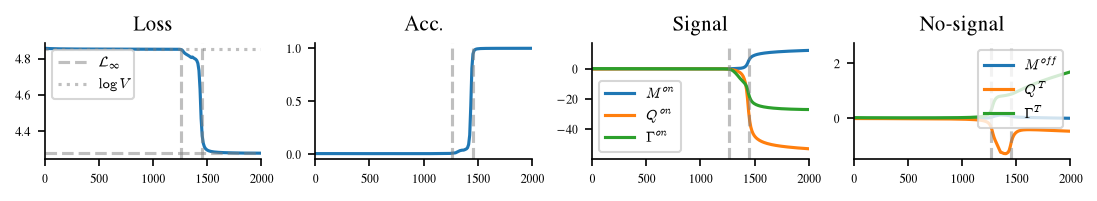

In [5]:

scalar_probes = {
    'Loss' : ["loss"],
    'Acc.': ["top1_accuracy"],
    'Signal': [('M_on', r'$M^{on}$' ),('Q_on',r'$Q^{on}$'),('G_on',r'$\Gamma^{on}$')],
    'No-signal': [('M_off', r'$M^{off}$' ),('Q_T',r'$Q^{T}$'),('G_T',r'$\Gamma^{T}$')],
}

fig , axes = create_fig(ncols=len(scalar_probes),size='double',h=0.17)

for i, (name, probes) in enumerate(scalar_probes.items()):
    ax = axes[i]
    label = None
    for probe in probes:
        if isinstance(probe, tuple):
            probe, label = probe
        ax.plot(steps, metrics[probe], label=label)
    ax.set_title(name)
    if probe == "loss":
        ax.axhline(L_inf, color='gray', linestyle='--', alpha=0.5, label=r'$\mathcal{L}_\infty$')
        ax.axhline(log_V, color='gray', linestyle=':', alpha=0.5, label=r'$\log V$')
        label = r'$\mathcal{L}_\infty$'
    if label is not None: ax.legend(fontsize=7,frameon=True)


for ax in axes:
    for T in (T1, T2):
        ax.axvline(T, color='gray', linestyle='--', alpha=0.5)

ax.set_xlim(left=00,right=2000)
    

(0.0, 2000.0)

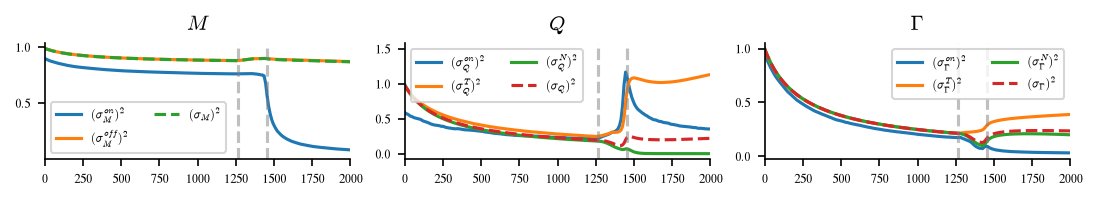

In [6]:
scalar_probes = {
    r'$M$' : [('var_M_on',r'$(\sigma_M^{on})^2$'),('var_M_off',r'$(\sigma_M^{off})^2$'),('var_M',r'$(\sigma_M)^2$'),], #('var_M',r'$(\sigma_M)^2$')
    r'$Q$': [('var_Q_on',r'$(\sigma_Q^{on})^2$'),('var_Q_T',r'$(\sigma_Q^{T})^2$'),('var_Q_N',r'$(\sigma_Q^{N})^2$'),('var_Q',r'$(\sigma_Q)^2$')],
    r'$\Gamma$': [('var_G_on',r'$(\sigma_\Gamma^{on})^2$'),('var_G_T',r'$(\sigma_\Gamma^{T})^2$'),('var_G_N',r'$(\sigma_\Gamma^{N})^2$'),('var_G',r'$(\sigma_\Gamma)^2$')]
}

fig , axes = create_fig(ncols=len(scalar_probes),size='double',h=0.17)

for i, (name, probes) in enumerate(scalar_probes.items()):
    ax = axes[i]
    label = None
    for probe in probes:
        if isinstance(probe, tuple):
            probe, label = probe
            ls = 'dashed' if  len(probe.split('_')) == 2 else 'solid'
        ax.plot(steps, metrics[probe], label=label, linestyle=ls)
    ax.set_title(name)
   
    if label is not None: ax.legend(fontsize=6,frameon=True,ncols=2)


for ax in axes:
    for T in (T1, T2):
        ax.axvline(T, color='gray', linestyle='--', alpha=0.5)

ax.set_xlim(left=00,right=2000)
    

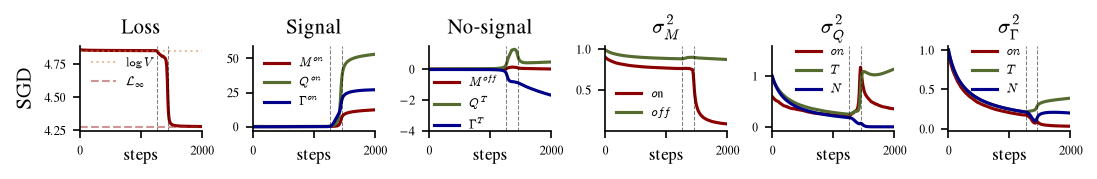

In [63]:

scalar_probes = {
    'Loss' : ["loss"],
    'Signal': [('M_on', r'$M^{on}$' ),('Q_on',r'$Q^{on}$'),('G_on',r'$\Gamma^{on}$')],
    'No-signal': [('M_off', r'$M^{off}$' ),('Q_T',r'$Q^{T}$'),('G_T',r'$\Gamma^{T}$')],
    r'$\sigma_M^2$' : [('var_M_on',r'$o$n'),('var_M_off',r'$off$'),], #('var_M',r'$(\sigma_M)^2$')
    r'$\sigma_Q^2$': [('var_Q_on',r'$on$'),('var_Q_T',r'$T$'),('var_Q_N',r'$N$')],
    r'$\sigma_\Gamma^2$': [('var_G_on',r'$on$'),('var_G_T',r'$T$'),('var_G_N',r'$N$')]
}

fig , axes = create_fig(ncols=len(scalar_probes),size='double',h=0.15)

for i, (name, probes) in enumerate(scalar_probes.items()):
    ax = axes[i]
    ax.set_prop_cycle(color=['darkred','darkolivegreen','darkblue'])
    label = None
    for probe in probes:
        if isinstance(probe, tuple):
            probe, label = probe
        sign = -1 if probe in ['Q_on','G_on','Q_T','G_T'] else 1
        ax.plot(steps, sign*metrics[probe], label=label,lw=1.5)
    ax.set_title(name)
    if probe == "loss":
        ax.axhline(log_V, color='peru', linestyle=':', alpha=0.5, label=r'$\log V$',lw=1)
        ax.axhline(L_inf, color='brown', linestyle='--', alpha=0.5, label=r'$\mathcal{L}_\infty$',lw=1)
        
        label = r'$\mathcal{L}_\infty$'
    # if label is not None: ax.legend(fontsize=6,frameon=False)

axes[2].set_ylim(-4,1.5)
for i , ax in enumerate(axes):
    for T in (T1, T2):
        ax.axvline(T, color='k', linestyle='--', alpha=0.5,lw=0.5)
    if i in [0,1]:
        loc = 'upper left'
    elif i in [4,5]:
        loc = (0.15,0.35)
    elif i == 3:
        loc = 'lower left'
    else:
        loc = (0.0,-0.08)
    # loc = 'upper left' if i in [0,1,4,5] else 'lower left'
    ax.legend(fontsize=6,frameon=False,loc=loc)
    ax.set_xticks([0,1000,2000],[0,None,2000])
    ax.set_xlabel('steps',fontsize=8,labelpad=-5)
    if i == 0:
        ax.set_ylabel(f'SGD')

ax.set_xlim(left=00,right=2000)


fig_name = 'sgd_metrics.pdf'
fig.savefig(path / fig_name, bbox_inches='tight',format='pdf')
    

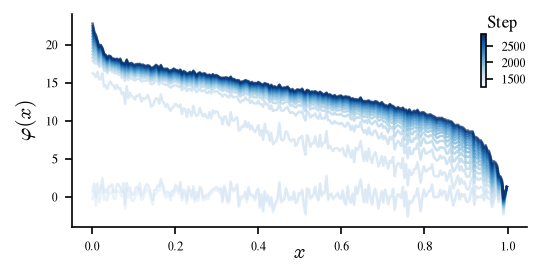

In [64]:
profile_steps = steps[(steps>T1) & (steps<2.*T2)][::10]
colors = plt.get_cmap('Blues')(np.linspace(0.1, 1, len(profile_steps)))
x = np.arange(1, L)/L

fig , axes = create_fig()

ax = axes
ax.set_prop_cycle(color=colors)

# Define a slice of evety 2 steps to reduce the number of points plotted as ::2
slc = slice(None,None,2)

for i, step in enumerate(profile_steps):
    profile = run.profile(step)[slc]
    ax.plot(x[slc],profile,lw=1.2,alpha=0.7)

ax.set_xlabel(r'$x$',labelpad=-5)
ax.set_ylabel(r'$\varphi(x)$')

# Insert an axes for a colorbar
cax = fig.add_axes([0.9, 0.7, 0.01, 0.2])  # [left, bottom, width, height]
norm = mpl.colors.Normalize(vmin=profile_steps.min(), vmax=profile_steps.max())
sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
cbar = fig.colorbar(sm, cax=cax)

fig.text(0.94, 0.94, 'Step', ha='center', va='center', fontsize=8)

fig_name = 'sgd_profiles.pdf'
fig.savefig(path / fig_name, bbox_inches='tight',format='pdf')


## Histograms

In [65]:
mus = (np.array([0.5,0.75,1.0])*L).astype(int)
table = logit_table(run.model(device=DEVICE),run.batch(NUM_SAMPLES,device=DEVICE),mus=mus,chunk=CHUNK_SIZE)
blocks = logit_blocks(K,V)
print(table.keys())
print(blocks.keys())

dict_keys(['logits', 'mu', 'ell', 'sequence_index', 'K'])
dict_keys(['triggers', 'other_outputs', 'rest', 'target', 'non_target'])


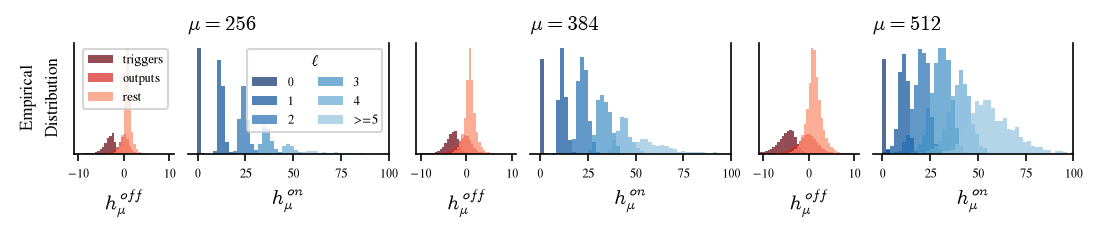

In [76]:
max_ell = 5
off_names = ['triggers','other_outputs','rest']

ranges = {'on': (table['logits'][:,-1].min().item(), table['logits'][:,-1].max().item()),
          'off': (table['logits'][:,:-2].min().item(), table['logits'][:,:-2].max().item())}

colors = {'on': plt.get_cmap('Blues_r')(np.linspace(0., 0.6, max_ell+1)),
          'off': plt.get_cmap('Reds_r')(np.linspace(0., 0.6, len(off_names)))}

limits = {'on': (-5, 100), 'off': (-11, 11)}

x_labels = {'on': r'$h_{\mu}^{on}$', 'off': r'$h_{\mu}^{off}$'}

fig , axes = create_fig(ncols=2*len(mus),nrows=1,size='double',h=0.2,sharey=False,w_ratios=[0.5,1]*len(mus),sharex=False)

plot_histograms(axes, table, blocks, mus, off_names, max_ell, ranges, colors, limits, x_labels)
axes[0].set_ylabel(f'Empirical\nDistribution',fontsize=8)

fig_name = 'empirical_logit_distribution.pdf'
fig.savefig(path / fig_name, bbox_inches='tight',format='pdf')

## Theoretical histograms (sampled)

In [77]:
# Sample Variables : sequence + gaussians and fix them 
step = 'last'

sampled_seq_variables = sample_variables(mu=table['mu'],ell=table['ell'],V=V,K=K,device=DEVICE,generator=generator)
normals = torch.randn(sampled_seq_variables.num_rows, V + 1, generator=generator, dtype=torch.float64, device=DEVICE)  
total_order_params = run.order_params(step=step,profile=True,variances=True)

print(total_order_params.keys())

dict_keys(['M_on', 'M_off', 'Q_on', 'Q_T', 'G_on', 'G_T', 'M_profile', 'var_M_on', 'var_M_off', 'var_Q_on', 'var_Q_T', 'var_Q_N', 'var_G_on', 'var_G_T', 'var_G_N', 'var_M', 'var_Q', 'var_G', 'var_M_on_raw'])


In [78]:
# Configurations of parameters to try

setups = {'signal_only' : ['M_on', 'Q_on', 'G_on']}
setups['means_only'] = setups['signal_only'] + ['M_off', 'Q_T', 'G_T']
setups['means_&_noise'] = setups['means_only'] + ['var_M_on', 'var_M_off', 'var_Q_on', 'var_Q_T', 'var_Q_N', 'var_G_on', 'var_G_T', 'var_G_N']
setups['means_&_profile'] = setups['means_only'] + ['M_profile'] 
setups['means,_noise_&_profile'] = setups['means_&_noise'] + ['M_profile']


sampled_tables = {}
for setup_name, params in setups.items():
    order_params = {k: total_order_params[k] for k in params}
    sampled_logits = sample_logits(sampled_seq_variables,order_params,beta,L,normals=normals).cpu()
    sampled_tables[setup_name] = QueryTable({"logits": sampled_logits, "mu": table['mu'], "ell": table['ell']})


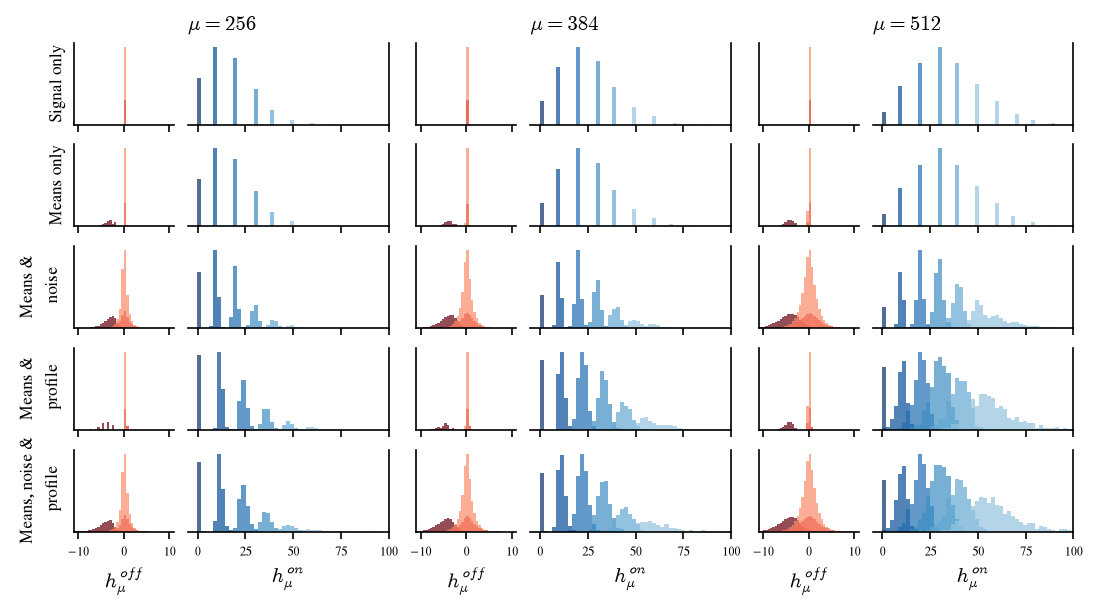

In [80]:
fig , axes = create_fig(ncols=2*len(mus),nrows=len(setups), size='double',h=0.11*len(setups),sharey=False,w_ratios=[0.5,1]*len(mus),sharex='col')

for i , (setup_name, sampled_table) in enumerate(sampled_tables.items()):
    axs = axes[i]
    axs[0].set_ylabel(setup_name.replace('_',' ').replace('&','&\n').capitalize(),fontsize=8)
    plot_histograms(axs, sampled_table, blocks, mus, off_names, max_ell, ranges, colors, limits, x_labels, show_legend=False, show_title=True if i==0 else False, show_xlabel=True if i==len(setups)-1 else False)

fig_name = 'sampled_logit_distribution.pdf'
fig.savefig(path / fig_name, bbox_inches='tight',format='pdf')

## Plot matrices

In [ ]:
mtxs = run.matrices()


dict_keys(['M', 'Q', 'G'])